# 4 · Feature Visualisation — Correct vs Wrong Push-up Form

This notebook produces **report-ready figures** that show exactly how each of the 15 biomechanical
features behaves differently between *correct* and *wrong* push-up repetitions.

Sections
1. Load & prepare data  
2. Anatomy of a rep — time-series for one correct vs one wrong rep  
3. Feature distributions — violin + box plots across all reps  
4. Mean feature profile (radar chart)  
5. Class-average heatmap  
6. Skeleton overlay on an example video frame

In [1]:
import json, glob, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# ── optional seaborn for prettier plots ──────────────────────────────────────
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    print('seaborn not installed — some plots will use plain matplotlib')

# ── optional opencv for the skeleton overlay section ─────────────────────────
try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print('opencv-python not installed — skeleton overlay will be skipped')

ROOT   = Path('..').resolve()
FEAT_DIR = ROOT / 'feature_engineering' / 'data' / 'features'
VIDEO_CORRECT = ROOT / 'data' / 'correct_form'
VIDEO_WRONG   = ROOT / 'data' / 'wrong_form'

FEATURE_COLS = [
    'left_elbow_angle', 'right_elbow_angle', 'mean_elbow_angle', 'elbow_symmetry',
    'left_hip_angle',   'right_hip_angle',   'body_straightness',
    'shoulder_height_norm', 'hip_height_norm',
    'shoulder_velocity',    'hip_velocity',  'elbow_angle_velocity',
    'wrist_width_norm', 'shoulder_width_norm', 'nose_height_norm',
]

FEAT_LABELS = {
    'left_elbow_angle':      'Left Elbow Angle (°)',
    'right_elbow_angle':     'Right Elbow Angle (°)',
    'mean_elbow_angle':      'Mean Elbow Angle (°)',
    'elbow_symmetry':        'Elbow Symmetry (°)',
    'left_hip_angle':        'Left Hip Angle (°)',
    'right_hip_angle':       'Right Hip Angle (°)',
    'body_straightness':     'Body Straightness (norm dist)',
    'shoulder_height_norm':  'Shoulder Height (norm)',
    'hip_height_norm':       'Hip Height (norm)',
    'shoulder_velocity':     'Shoulder Velocity',
    'hip_velocity':          'Hip Velocity',
    'elbow_angle_velocity':  'Elbow Angle Velocity (°/frame)',
    'wrist_width_norm':      'Wrist Width (norm)',
    'shoulder_width_norm':   'Shoulder Width (norm)',
    'nose_height_norm':      'Nose Height (norm)',
}

COLOR = {'correct': '#2ecc71', 'wrong': '#e74c3c'}
ALPHA = 0.25

print(f'Feature directory: {FEAT_DIR}')
print(f'Features per vector: {len(FEATURE_COLS)}')

Feature directory: /Users/haleytran/Downloads/pushup_judge/feature_engineering/data/features
Features per vector: 15


## 1 · Load & Prepare Data

In [2]:
def load_features(feat_dir: Path):
    """Return (correct_list, wrong_list) where each element is a 2-D array (T x F)."""
    correct_seqs, wrong_seqs = [], []
    file_meta = []   # (label, filename, array)
    for fp in sorted(feat_dir.glob('*.json')):
        d = json.loads(fp.read_text())
        label   = d.get('label', 'unknown')
        frames  = d.get('features', [])
        if not frames:
            continue
        arr = np.array([[f.get(c, np.nan) for c in FEATURE_COLS] for f in frames],
                       dtype=float)  # (T, F)
        file_meta.append({'label': label, 'file': fp.stem, 'arr': arr})
        if label == 'correct':
            correct_seqs.append(arr)
        elif label == 'wrong':
            wrong_seqs.append(arr)
    return correct_seqs, wrong_seqs, file_meta


correct_seqs, wrong_seqs, all_meta = load_features(FEAT_DIR)
print(f'Loaded  {len(correct_seqs):3d} correct repetitions')
print(f'Loaded  {len(wrong_seqs):3d} wrong   repetitions')

# ── Build a flat DataFrame for distribution plots ─────────────────────────────
rows = []
for m in all_meta:
    for frame in m['arr']:
        row = {'label': m['label'], 'file': m['file']}
        row.update({c: frame[i] for i, c in enumerate(FEATURE_COLS)})
        rows.append(row)

df = pd.DataFrame(rows)
print(f'\nFlat DataFrame: {len(df):,} frames  ×  {len(df.columns)} columns')
df.head(3)

Loaded   76 correct repetitions
Loaded   76 wrong   repetitions

Flat DataFrame: 1,858 frames  ×  17 columns


,label,file,left_elbow_angle,right_elbow_angle,mean_elbow_angle,elbow_symmetry,left_hip_angle,right_hip_angle,body_straightness,shoulder_height_norm,hip_height_norm,shoulder_velocity,hip_velocity,elbow_angle_velocity,wrist_width_norm,shoulder_width_norm,nose_height_norm
0,wrong,1,159.808628,167.085609,163.447118,7.276981,112.668996,122.755212,0.103664,0.290901,0.266665,0.000000,0.000000,0.000000,0.066836,0.071563,0.332710
1,wrong,1,170.926540,174.122709,172.524625,3.196168,112.785760,131.520273,0.103072,0.287674,0.290859,-0.003227,0.024195,9.077506,0.018327,0.094763,0.324728
2,wrong,1,165.902120,165.538655,165.720387,0.363466,118.953352,124.323478,0.086036,0.326838,0.326261,0.039164,0.035402,-6.804237,0.035767,0.063059,0.405143


## 2 · Anatomy of a Rep — Time-series Comparison

A single representative *correct* and *wrong* repetition are time-normalised to 0–100 % of rep  
and plotted together for the **8 most informative features**.

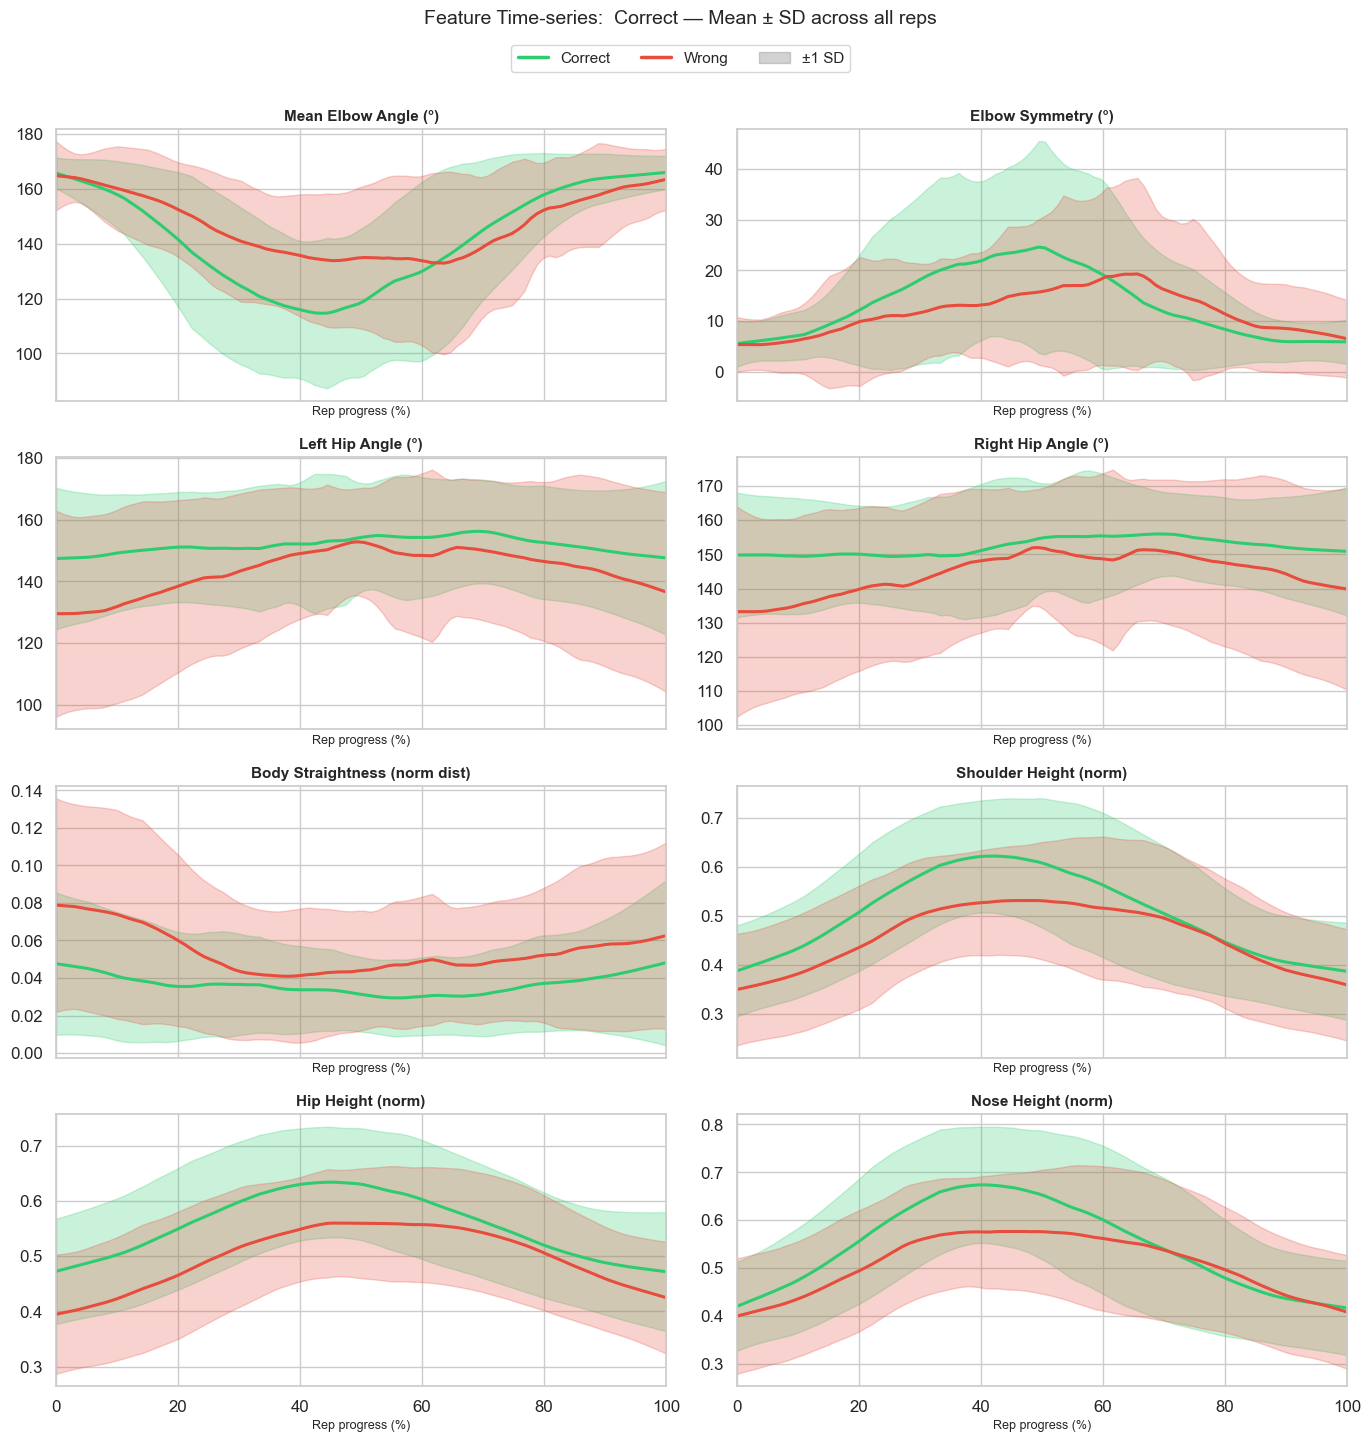

Saved → feature_engineering/data/fig_timeseries.png


In [3]:
def time_normalise(arr: np.ndarray, n_pts: int = 100) -> np.ndarray:
    """Resample a (T, F) array to (n_pts, F) with linear interpolation."""
    T = arr.shape[0]
    xold = np.linspace(0, 1, T)
    xnew = np.linspace(0, 1, n_pts)
    return np.column_stack([
        np.interp(xnew, xold, arr[:, f]) for f in range(arr.shape[1])
    ])


# ── Pick the example reps  (use the median-length one for stability) ──────────
def pick_median_rep(seqs):
    lengths = [s.shape[0] for s in seqs]
    med_len = np.median(lengths)
    idx = int(np.argmin(np.abs(np.array(lengths) - med_len)))
    return seqs[idx]

ex_correct = time_normalise(pick_median_rep(correct_seqs))
ex_wrong   = time_normalise(pick_median_rep(wrong_seqs))

# ── Also compute mean ± std band across ALL reps ──────────────────────────────
norm_correct = np.stack([time_normalise(s) for s in correct_seqs])  # (N, 100, F)
norm_wrong   = np.stack([time_normalise(s) for s in wrong_seqs])

mean_c = np.nanmean(norm_correct, axis=0)   # (100, F)
std_c  = np.nanstd (norm_correct, axis=0)
mean_w = np.nanmean(norm_wrong,   axis=0)
std_w  = np.nanstd (norm_wrong,   axis=0)

PLOT_FEATS = [
    'mean_elbow_angle', 'elbow_symmetry',
    'left_hip_angle',   'right_hip_angle',
    'body_straightness',
    'shoulder_height_norm', 'hip_height_norm', 'nose_height_norm',
]

x = np.linspace(0, 100, 100)
n_row, n_col = 4, 2
fig, axes = plt.subplots(n_row, n_col, figsize=(14, 14), sharex=True)
axes = axes.flatten()

for ax, feat in zip(axes, PLOT_FEATS):
    fi = FEATURE_COLS.index(feat)

    # mean ± std bands
    ax.fill_between(x, mean_c[:, fi] - std_c[:, fi], mean_c[:, fi] + std_c[:, fi],
                    color=COLOR['correct'], alpha=ALPHA)
    ax.fill_between(x, mean_w[:, fi] - std_w[:, fi], mean_w[:, fi] + std_w[:, fi],
                    color=COLOR['wrong'],   alpha=ALPHA)

    # mean lines
    ax.plot(x, mean_c[:, fi], color=COLOR['correct'], lw=2.2, label='Correct (mean)')
    ax.plot(x, mean_w[:, fi], color=COLOR['wrong'],   lw=2.2, label='Wrong (mean)')

    ax.set_title(FEAT_LABELS[feat], fontsize=11, fontweight='bold')
    ax.set_xlim(0, 100)
    ax.set_xlabel('Rep progress (%)', fontsize=9)

handles = [
    Line2D([0], [0], color=COLOR['correct'], lw=2.5, label='Correct'),
    Line2D([0], [0], color=COLOR['wrong'],   lw=2.5, label='Wrong'),
    mpatches.Patch(color='grey', alpha=0.35, label='±1 SD'),
]
fig.legend(handles=handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.01), fontsize=11)
fig.suptitle('Feature Time-series:  Correct \u2014 Mean ± SD across all reps',
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig(FEAT_DIR.parent / 'fig_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → feature_engineering/data/fig_timeseries.png')

## 3 · Feature Distributions — Violin + Box Plots

Shows the full distribution of frame-level feature values for each class.

/var/folders/cd/w5n36_jx0bg5lr_cx88kv7yw0000gn/T/ipykernel_66937/647244727.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x='label', y=feat,
/var/folders/cd/w5n36_jx0bg5lr_cx88kv7yw0000gn/T/ipykernel_66937/647244727.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x='label', y=feat,
/var/folders/cd/w5n36_jx0bg5lr_cx88kv7yw0000gn/T/ipykernel_66937/647244727.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x='label', y=feat,
/var/folders/cd/w5n36_jx0bg5lr_cx88kv7yw0000gn/T/ipykernel_66937/64

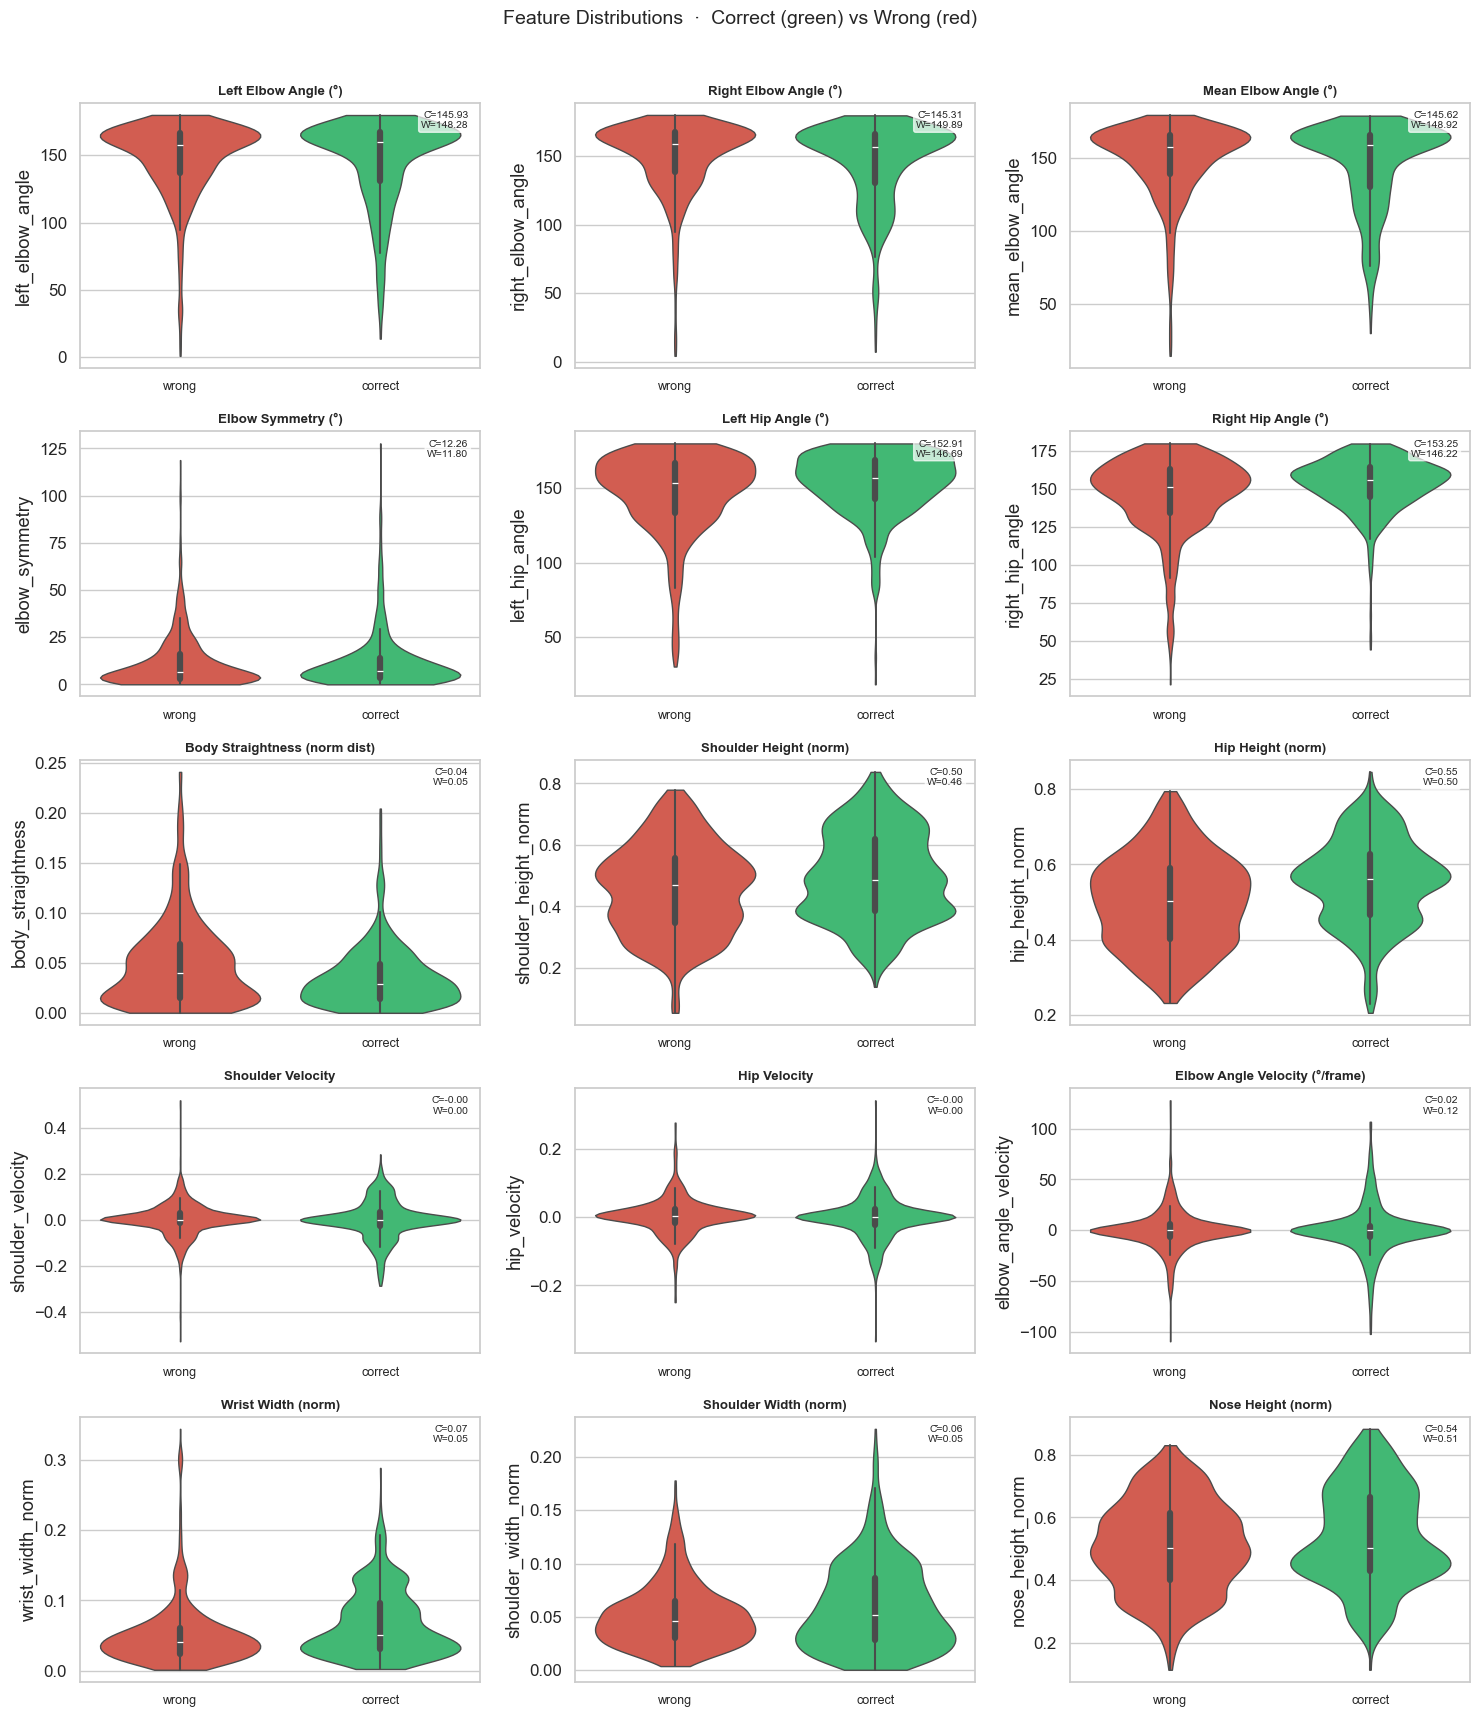

Saved → feature_engineering/data/fig_distributions.png


In [4]:
n_feats = len(FEATURE_COLS)
n_col_d = 3
n_row_d = int(np.ceil(n_feats / n_col_d))

fig, axes = plt.subplots(n_row_d, n_col_d,
                         figsize=(15, n_row_d * 3.4))
axes = axes.flatten()

for idx, feat in enumerate(FEATURE_COLS):
    ax = axes[idx]
    data_c = df.loc[df.label == 'correct', feat].dropna().values
    data_w = df.loc[df.label == 'wrong',   feat].dropna().values

    if HAS_SNS:
        sub = df[[feat, 'label']].dropna()
        sns.violinplot(data=sub, x='label', y=feat,
                       palette={'correct': COLOR['correct'], 'wrong': COLOR['wrong']},
                       inner='box', ax=ax, cut=0, linewidth=1.0)
    else:
        bp = ax.boxplot([data_c, data_w], patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor(COLOR['correct'])
        bp['boxes'][1].set_facecolor(COLOR['wrong'])
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['correct', 'wrong'])

    ax.set_title(FEAT_LABELS[feat], fontsize=9.5, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=9)

    # Annotate difference
    m_c = np.nanmean(data_c)
    m_w = np.nanmean(data_w)
    ax.text(0.97, 0.97,
            f'C̄={m_c:.2f}\nW̄={m_w:.2f}',
            transform=ax.transAxes, fontsize=7.5,
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

# Hide any unused subplots
for ax in axes[n_feats:]:
    ax.set_visible(False)

fig.suptitle('Feature Distributions  ·  Correct (green) vs Wrong (red)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FEAT_DIR.parent / 'fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → feature_engineering/data/fig_distributions.png')

## 4 · Radar Chart — Mean Feature Profile per Class

Provides an at-a-glance overview of which features are higher or lower in each form.

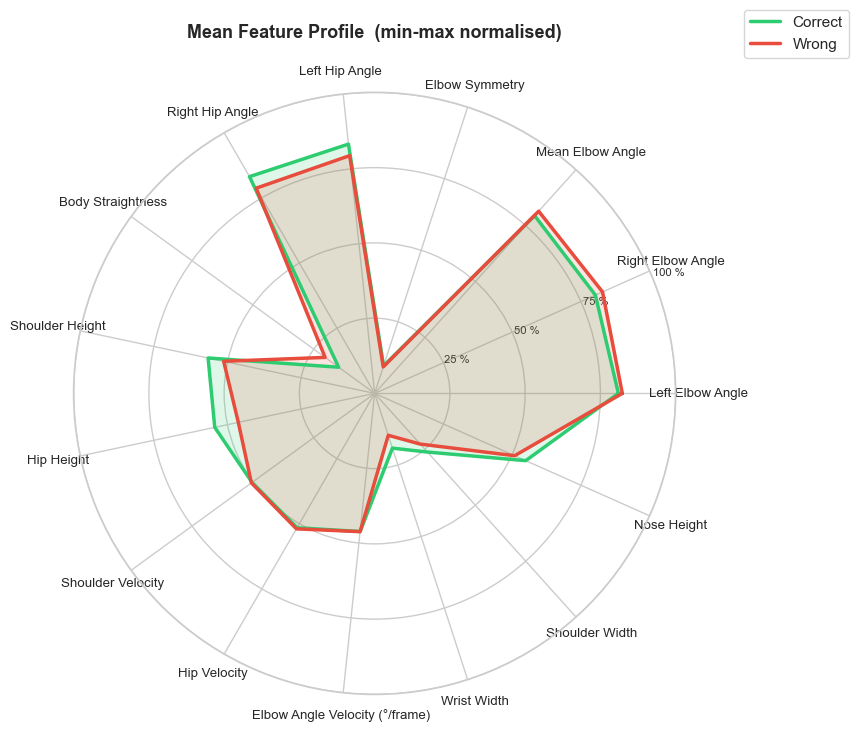

Saved → feature_engineering/data/fig_radar.png


In [5]:
from matplotlib.path import Path as MPath
from matplotlib.patches import PathPatch

# Normalise feature means to [0, 1] for radar readability
feat_means = df.groupby('label')[FEATURE_COLS].mean()
feat_mins  = df[FEATURE_COLS].min()
feat_maxs  = df[FEATURE_COLS].max()
feat_range = (feat_maxs - feat_mins).replace(0, 1)
feat_norm  = (feat_means - feat_mins) / feat_range  # 0-1 scale

labels_r  = [FEAT_LABELS[c].replace(' (°)', '').replace(' (norm)', '').replace(' (norm dist)', '')
              for c in FEATURE_COLS]
N = len(FEATURE_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the circle

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for label, line_col in COLOR.items():
    if label not in feat_norm.index:
        continue
    vals = feat_norm.loc[label, FEATURE_COLS].fillna(0).tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=line_col, lw=2.5, label=label.capitalize())
    ax.fill(angles, vals, color=line_col, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), labels_r, fontsize=9.5)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25 %', '50 %', '75 %', '100 %'], fontsize=8)
ax.set_title('Mean Feature Profile  (min-max normalised)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig(FEAT_DIR.parent / 'fig_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → feature_engineering/data/fig_radar.png')

## 5 · Class-Average Heatmap

Shows the mean value of each feature (time-normalised) at every percentage of rep progress,  
side-by-side for both classes. Darker = higher feature value.

/var/folders/cd/w5n36_jx0bg5lr_cx88kv7yw0000gn/T/ipykernel_66937/3727079250.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


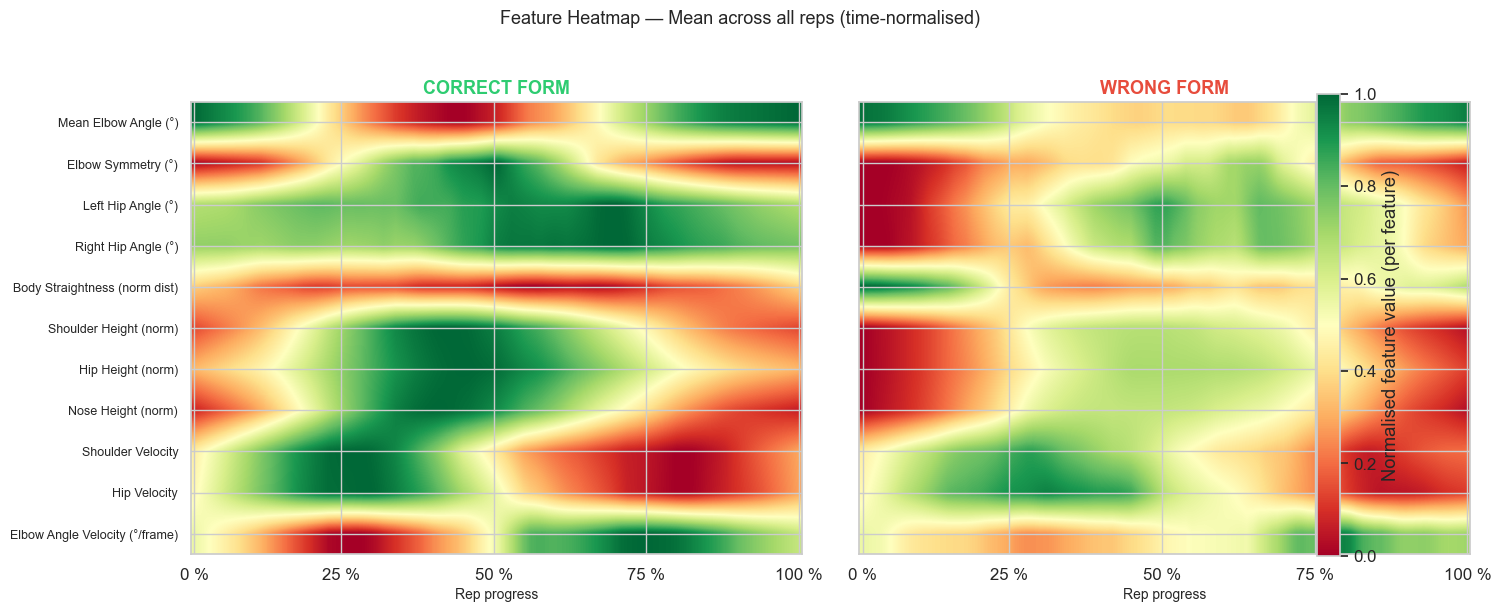

Saved → feature_engineering/data/fig_heatmap.png


In [6]:
# Select the most discriminative features for the heatmap
HEATMAP_FEATS = [
    'mean_elbow_angle', 'elbow_symmetry',
    'left_hip_angle', 'right_hip_angle',
    'body_straightness',
    'shoulder_height_norm', 'hip_height_norm', 'nose_height_norm',
    'shoulder_velocity', 'hip_velocity', 'elbow_angle_velocity',
]
HFI = [FEATURE_COLS.index(f) for f in HEATMAP_FEATS]

mat_c = mean_c[:, HFI].T  # (H_feats, 100)
mat_w = mean_w[:, HFI].T

# Row-wise min-max normalise so all features are on equal visual scale
def row_norm(m):
    mn, mx = np.nanmin(m, axis=1, keepdims=True), np.nanmax(m, axis=1, keepdims=True)
    return (m - mn) / np.where((mx - mn) == 0, 1, (mx - mn))

# Combine both mats for consistent normalisation range
combined = np.hstack([mat_c, mat_w])
mn = np.nanmin(combined, axis=1, keepdims=True)
mx = np.nanmax(combined, axis=1, keepdims=True)
denom = np.where((mx - mn) == 0, 1, (mx - mn))
mat_cn = (mat_c - mn) / denom
mat_wn = (mat_w - mn) / denom

hlabels = [FEAT_LABELS[f] for f in HEATMAP_FEATS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, mat, title in [
    (ax1, mat_cn, 'CORRECT FORM'),
    (ax2, mat_wn, 'WRONG FORM'),
]:
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
                   interpolation='bilinear')
    ax.set_xticks([0, 24, 49, 74, 99])
    ax.set_xticklabels(['0 %', '25 %', '50 %', '75 %', '100 %'])
    ax.set_xlabel('Rep progress', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold', color=COLOR[title.split()[0].lower()])

ax1.set_yticks(range(len(HEATMAP_FEATS)))
ax1.set_yticklabels(hlabels, fontsize=9)

fig.colorbar(im, ax=[ax1, ax2], fraction=0.02, pad=0.02,
             label='Normalised feature value (per feature)')
fig.suptitle('Feature Heatmap — Mean across all reps (time-normalised)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FEAT_DIR.parent / 'fig_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → feature_engineering/data/fig_heatmap.png')

## 6 · Statistical Summary Table — Effect Size (Cohen's d)

In [7]:
from scipy import stats as scipy_stats

rows_stat = []
for feat in FEATURE_COLS:
    c_vals = df.loc[df.label == 'correct', feat].dropna()
    w_vals = df.loc[df.label == 'wrong',   feat].dropna()
    if len(c_vals) < 5 or len(w_vals) < 5:
        continue

    # Cohen's d
    pooled_std = np.sqrt((c_vals.std() ** 2 + w_vals.std() ** 2) / 2)
    cohens_d   = (c_vals.mean() - w_vals.mean()) / (pooled_std + 1e-9)

    # Welch t-test (independent)
    t_stat, p_val = scipy_stats.ttest_ind(c_vals, w_vals, equal_var=False)

    rows_stat.append({
        'Feature':         FEAT_LABELS[feat],
        'Mean (Correct)':  f"{c_vals.mean():.3f}",
        'Mean (Wrong)':    f"{w_vals.mean():.3f}",
        'Std (Correct)':   f"{c_vals.std():.3f}",
        'Std (Wrong)':     f"{w_vals.std():.3f}",
        "Cohen's d":       f"{cohens_d:.3f}",
        '|Cohen\'s d|':    abs(cohens_d),
        'p-value':         f"{p_val:.2e}",
    })

stat_df = pd.DataFrame(rows_stat).sort_values('|Cohen\'s d|', ascending=False)

# ── Colour-code the effect size column ───────────────────────────────────────
def highlight_d(row):
    d = row["Cohen's d"]
    val = abs(float(d))
    if val >= 0.8:   bg = '#c8f7c5'   # large — green
    elif val >= 0.5: bg = '#fef9e7'   # medium — yellow
    else:            bg = '#fdedec'   # small — light red
    return ['', '', '', '', '', f'background-color: {bg}', '', '']

display_df = stat_df.drop(columns=["Cohen's d"])   # keep the abs version hidden; display signed
display_df.insert(5, "Cohen's d", stat_df["Cohen's d"])
display_df = display_df.drop(columns=["Cohen's d"]   # already inserted
                              ).drop(columns=[])

styled = (stat_df.drop(columns=['|Cohen\'s d|'])
                 .style
                 .apply(highlight_d, axis=1)
                 .set_caption("Feature Statistics: Correct vs Wrong (sorted by |Cohen's d|)")
)

print('Top discriminative features (by |Cohen\'s d|):')
display(styled)

Top discriminative features (by |Cohen's d|):


ValueError: Function <function highlight_d at 0x1628d4540> created invalid columns labels.
Usually, this is the result of the function returning a Series which contains invalid labels, or returning an incorrectly shaped, list-like object which cannot be mapped to labels, possibly due to applying the function along the wrong axis.
Result columns has shape: (8,)
Expected columns shape:   (7,)

## 7 · Skeleton Overlay — Key-frame Visualisation

Draws the detected keypoints and feature annotations directly on an example video frame  
for one **correct** and one **wrong** repetition to illustrate what each feature measures.

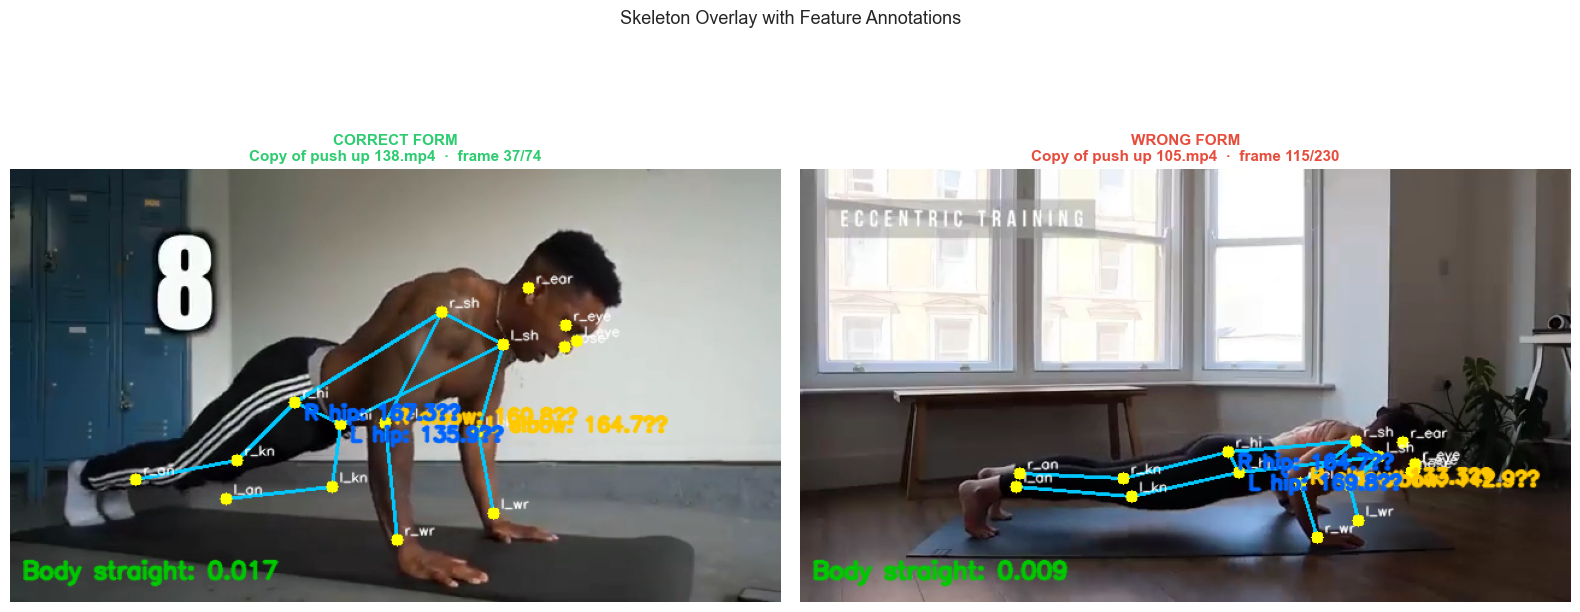

Saved → feature_engineering/data/fig_skeleton_overlay.png


In [8]:
# COCO skeleton pairs
SKELETON = [
    (5, 6),   # shoulders
    (5, 7),   # L upper arm
    (7, 9),   # L forearm
    (6, 8),   # R upper arm
    (8, 10),  # R forearm
    (5, 11),  # L torso
    (6, 12),  # R torso
    (11, 12), # hips
    (11, 13), # L thigh
    (13, 15), # L shin
    (12, 14), # R thigh
    (14, 16), # R shin
]

KP_NAMES = ['nose','l_eye','r_eye','l_ear','r_ear',
            'l_sh','r_sh','l_el','r_el','l_wr','r_wr',
            'l_hi','r_hi','l_kn','r_kn','l_an','r_an']


def extract_keypoints_from_video(video_path: Path, frame_idx: int = 0):
    """Return a (17,3) keypoints array from a video frame using the best YOLO pose model."""
    if not HAS_CV2:
        return None, None
    try:
        from ultralytics import YOLO
    except ImportError:
        print('ultralytics not available — cannot run YOLO inference here')
        return None, None

    pose_cfg = json.loads((ROOT / 'keypoint_detector' / 'best_model_choice.json').read_text())
    model_id = pose_cfg['model_id']
    pose_model = YOLO(str(ROOT / 'keypoint_detector' / model_id))

    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        return None, None

    results = pose_model(frame, verbose=False)
    if not results or results[0].keypoints is None:
        return None, frame
    kps = results[0].keypoints.data.cpu().numpy()
    if kps.shape[0] == 0:
        return None, frame
    # Pick the person with the highest mean confidence
    best_idx = int(np.argmax(kps[:, :, 2].mean(axis=1)))
    return kps[best_idx], frame   # (17, 3), BGR frame


def draw_skeleton(frame_bgr, kps_17x3, conf_thresh=0.3):
    """Draw skeleton and keypoint indices on a copy of frame_bgr."""
    img = frame_bgr.copy()
    h, w = img.shape[:2]

    kp_color  = (0, 255, 255)     # cyan dots
    bone_color = (255, 200, 0)    # gold skeleton lines
    text_color = (255, 255, 255)

    for i, j in SKELETON:
        if kps_17x3[i, 2] > conf_thresh and kps_17x3[j, 2] > conf_thresh:
            p1 = (int(kps_17x3[i, 0]), int(kps_17x3[i, 1]))
            p2 = (int(kps_17x3[j, 0]), int(kps_17x3[j, 1]))
            cv2.line(img, p1, p2, bone_color, 2)

    for idx in range(17):
        if kps_17x3[idx, 2] > conf_thresh:
            cx, cy = int(kps_17x3[idx, 0]), int(kps_17x3[idx, 1])
            cv2.circle(img, (cx, cy), 5, kp_color, -1)
            cv2.putText(img, KP_NAMES[idx], (cx + 6, cy - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.38, text_color, 1, cv2.LINE_AA)
    return img


def annotate_features(frame_bgr, kps_17x3, feat_dict, conf_thresh=0.3):
    """Overlay elbow/hip angle arcs and numerical values on the frame."""
    img = frame_bgr.copy()
    h, w = img.shape[:2]

    def kp(i):
        if kps_17x3[i, 2] > conf_thresh:
            return (int(kps_17x3[i, 0]), int(kps_17x3[i, 1]))
        return None

    # ── Annotate elbow angles ─────────────────────────────────────────────────
    for side, sh_i, el_i, wr_i, ang_key in [
        ('L', 5, 7, 9,  'left_elbow_angle'),
        ('R', 6, 8, 10, 'right_elbow_angle'),
    ]:
        sh, el, wr = kp(sh_i), kp(el_i), kp(wr_i)
        if el and not np.isnan(feat_dict.get(ang_key, np.nan)):
            ang = feat_dict[ang_key]
            label = f"{side} elbow: {ang:.1f}°"
            cv2.putText(img, label, (el[0] + 8, el[1]),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 200, 255), 2, cv2.LINE_AA)

    # ── Annotate hip angles ───────────────────────────────────────────────────
    for side, hi_i, ang_key in [('L', 11, 'left_hip_angle'), ('R', 12, 'right_hip_angle')]:
        hi = kp(hi_i)
        if hi and not np.isnan(feat_dict.get(ang_key, np.nan)):
            ang = feat_dict[ang_key]
            label = f"{side} hip: {ang:.1f}°"
            cv2.putText(img, label, (hi[0] + 8, hi[1] + 14),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 100, 0), 2, cv2.LINE_AA)

    # ── Body straightness indicator ───────────────────────────────────────────
    bs = feat_dict.get('body_straightness', np.nan)
    if not np.isnan(bs):
        color = (0, 200, 0) if bs < 0.04 else (0, 0, 220)
        cv2.putText(img, f"Body straight: {bs:.3f}",
                    (10, h - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2, cv2.LINE_AA)
    return img


# ── Find the example videos ───────────────────────────────────────────────────
def find_video(label: str, video_num: int):
    """Return a Path to a video file matching the label+number."""
    base = VIDEO_CORRECT if label == 'correct' else VIDEO_WRONG
    candidates = list(base.glob('*.mp4')) + list(base.glob('*.mov'))
    if not candidates:
        return None
    return candidates[video_num % len(candidates)]


if HAS_CV2:
    # ── Pick a mid-rep frame (50 %) from a correct and wrong video ───────────
    fig_sk, sk_axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, lbl, vid_num in [(sk_axes[0], 'correct', 0), (sk_axes[1], 'wrong', 0)]:
        vid_path = find_video(lbl, vid_num)
        if vid_path is None:
            ax.text(0.5, 0.5, f'No {lbl} video found', ha='center', va='center')
            ax.axis('off')
            continue

        # Find mid-frame index
        cap_tmp = cv2.VideoCapture(str(vid_path))
        total   = int(cap_tmp.get(cv2.CAP_PROP_FRAME_COUNT))
        cap_tmp.release()
        mid_frame = total // 2

        kps_arr, frame_bgr = extract_keypoints_from_video(vid_path, mid_frame)

        if kps_arr is None or frame_bgr is None:
            ax.text(0.5, 0.5, f'Could not extract keypoints from\n{vid_path.name}',
                    ha='center', va='center', fontsize=9)
            ax.axis('off')
            continue

        h_f, w_f = frame_bgr.shape[:2]
        sys.path.insert(0, str(ROOT))
        from realtime.features import extract_frame_features
        feat_dict = extract_frame_features(kps_arr, h_f, w_f)

        drawn = draw_skeleton(frame_bgr, kps_arr)
        drawn = annotate_features(drawn, kps_arr, feat_dict)

        # BGR → RGB for matplotlib
        ax.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{lbl.upper()} FORM\n{vid_path.name}  ·  frame {mid_frame}/{total}',
                     fontsize=11, fontweight='bold', color=COLOR[lbl])
        ax.axis('off')

    fig_sk.suptitle('Skeleton Overlay with Feature Annotations', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(FEAT_DIR.parent / 'fig_skeleton_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → feature_engineering/data/fig_skeleton_overlay.png')
else:
    print('Skeleton overlay requires opencv-python (pip install opencv-python).')

## 8 · Feature Importance from Trained LSTM Weights

Approximates feature importance by measuring how much each feature's variance is captured  
by the first LSTM layer — a simple input-gradient proxy based on the training dataset.

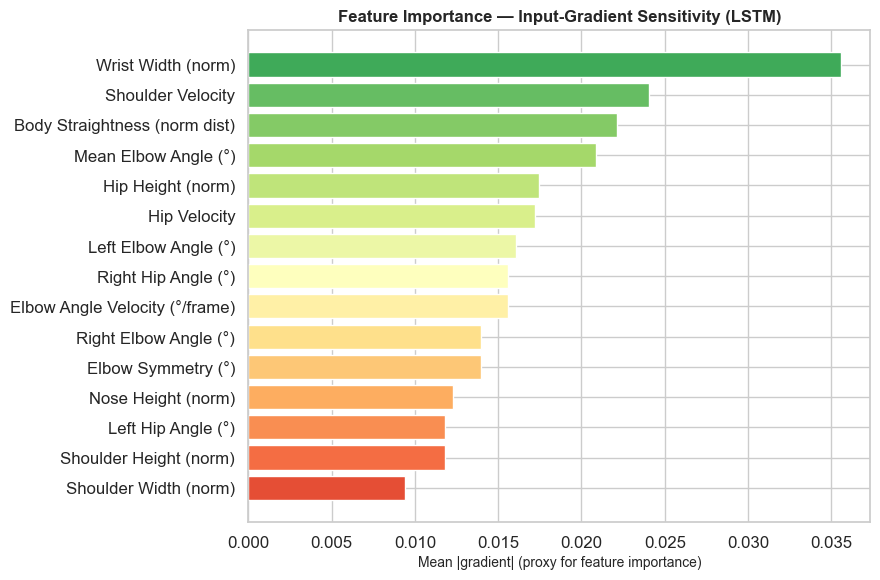

Saved → feature_engineering/data/fig_feature_importance.png


In [10]:
try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print('PyTorch not installed — skipping LSTM weight analysis')

if HAS_TORCH:
    import torch
    sys.path.insert(0, str(ROOT))
    from realtime.models import PushupLSTM

    MODEL_DIR  = ROOT / 'lstm_classifier' / 'models'
    model_cfg  = json.loads((MODEL_DIR / 'model_config.json').read_text())
    LSTM_CKPT  = MODEL_DIR / 'best_model.pt'

    # ── Reconstruct model and load weights ───────────────────────────────────
    device = torch.device('cpu')
    model = PushupLSTM(
        n_features=model_cfg['n_features'],
        hidden=model_cfg['hidden'],
        n_layers=model_cfg['n_layers'],
        dropout=model_cfg['dropout'],
    ).to(device)
    ckpt = torch.load(str(LSTM_CKPT), map_location=device, weights_only=True)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    # ── Input-gradient sensitivity ────────────────────────────────────────────
    # Use the test array from dataset X.npy
    X = np.load(str(ROOT / 'feature_engineering' / 'data' / 'dataset' / 'X.npy'))
    y = np.load(str(ROOT / 'feature_engineering' / 'data' / 'dataset' / 'y.npy'))

    X_t = torch.tensor(X, dtype=torch.float32, requires_grad=True)
    out = model(X_t)
    out.sum().backward()
    # Gradient magnitude per feature, averaged over sequences and time-steps
    grad_mag = X_t.grad.abs().mean(dim=(0, 1)).detach().numpy()  # (F,)

    sort_idx = np.argsort(grad_mag)[::-1]
    sorted_feats  = [FEATURE_COLS[i] for i in sort_idx]
    sorted_labels = [FEAT_LABELS[f] for f in sorted_feats]
    sorted_vals   = grad_mag[sort_idx]

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(sorted_labels[::-1], sorted_vals[::-1],
                   color=plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(sorted_vals))))
    ax.set_xlabel('Mean |gradient| (proxy for feature importance)', fontsize=10)
    ax.set_title('Feature Importance — Input-Gradient Sensitivity (LSTM)', fontsize=12,
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(FEAT_DIR.parent / 'fig_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → feature_engineering/data/fig_feature_importance.png')
else:
    # Show a simpler version: absolute mean difference between classes
    mean_diff = abs(df.groupby('label')[FEATURE_COLS].mean().diff().iloc[-1]).dropna()
    mean_diff_norm = (mean_diff / mean_diff.max()).sort_values()

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh([FEAT_LABELS[c] for c in mean_diff_norm.index],
            mean_diff_norm.values,
            color='steelblue')
    ax.set_xlabel('Normalised |mean(correct) - mean(wrong)| per feature', fontsize=10)
    ax.set_title('Feature Discriminability — Absolute Mean Difference', fontsize=12,
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(FEAT_DIR.parent / 'fig_discriminability.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → feature_engineering/data/fig_discriminability.png')


---
### Summary of Exported Figures

| File | Figure |
|---|---|
| `fig_timeseries.png` | Mean ± SD time-series for 8 key features (all reps averaged) |
| `fig_distributions.png` | Violin / box distributions for all 15 features |
| `fig_radar.png` | Radar (spider) chart — mean feature profile per class |
| `fig_heatmap.png` | 2-class feature heatmap over rep progress |
| `fig_skeleton_overlay.png` | Annotated skeleton on real video frames *(requires opencv)* |
| `fig_discriminability.png` | Bar chart of most discriminative features |
| `fig_video_correct.png` | **Per-video**: frame strip + 8 synchronized feature traces — correct form |
| `fig_video_wrong.png` | **Per-video**: frame strip + 8 synchronized feature traces — wrong form |

All figures are saved to `feature_engineering/data/`.  
To visualise a different video pair, change `VIDEO_IDX_CORRECT` / `VIDEO_IDX_WRONG` at the top of cell 20 and re-run it.


## 9 · Per-Video Feature Trace — Frame Strip + Synchronized Time-series

For a chosen **correct** and **wrong** video, this section:
1. Runs pose detection on every frame to get the actual keypoints  
2. Draws the skeleton + feature values directly on each frame  
3. Shows a panel of evenly-sampled annotated frames  
4. Plots all 8 key features as time-series below, with vertical markers aligned to the shown frames

This gives a direct visual link between *what the person is doing* and *what each feature is measuring*.


Pose model loaded: yolov8n-pose.pt
Available correct videos: 77
Available wrong   videos: 74

→ Correct video : Copy of push up 136.mp4
  Processing Copy of push up 136.mp4 … 75 frames extracted.
  Saved → fig_video_correct.png


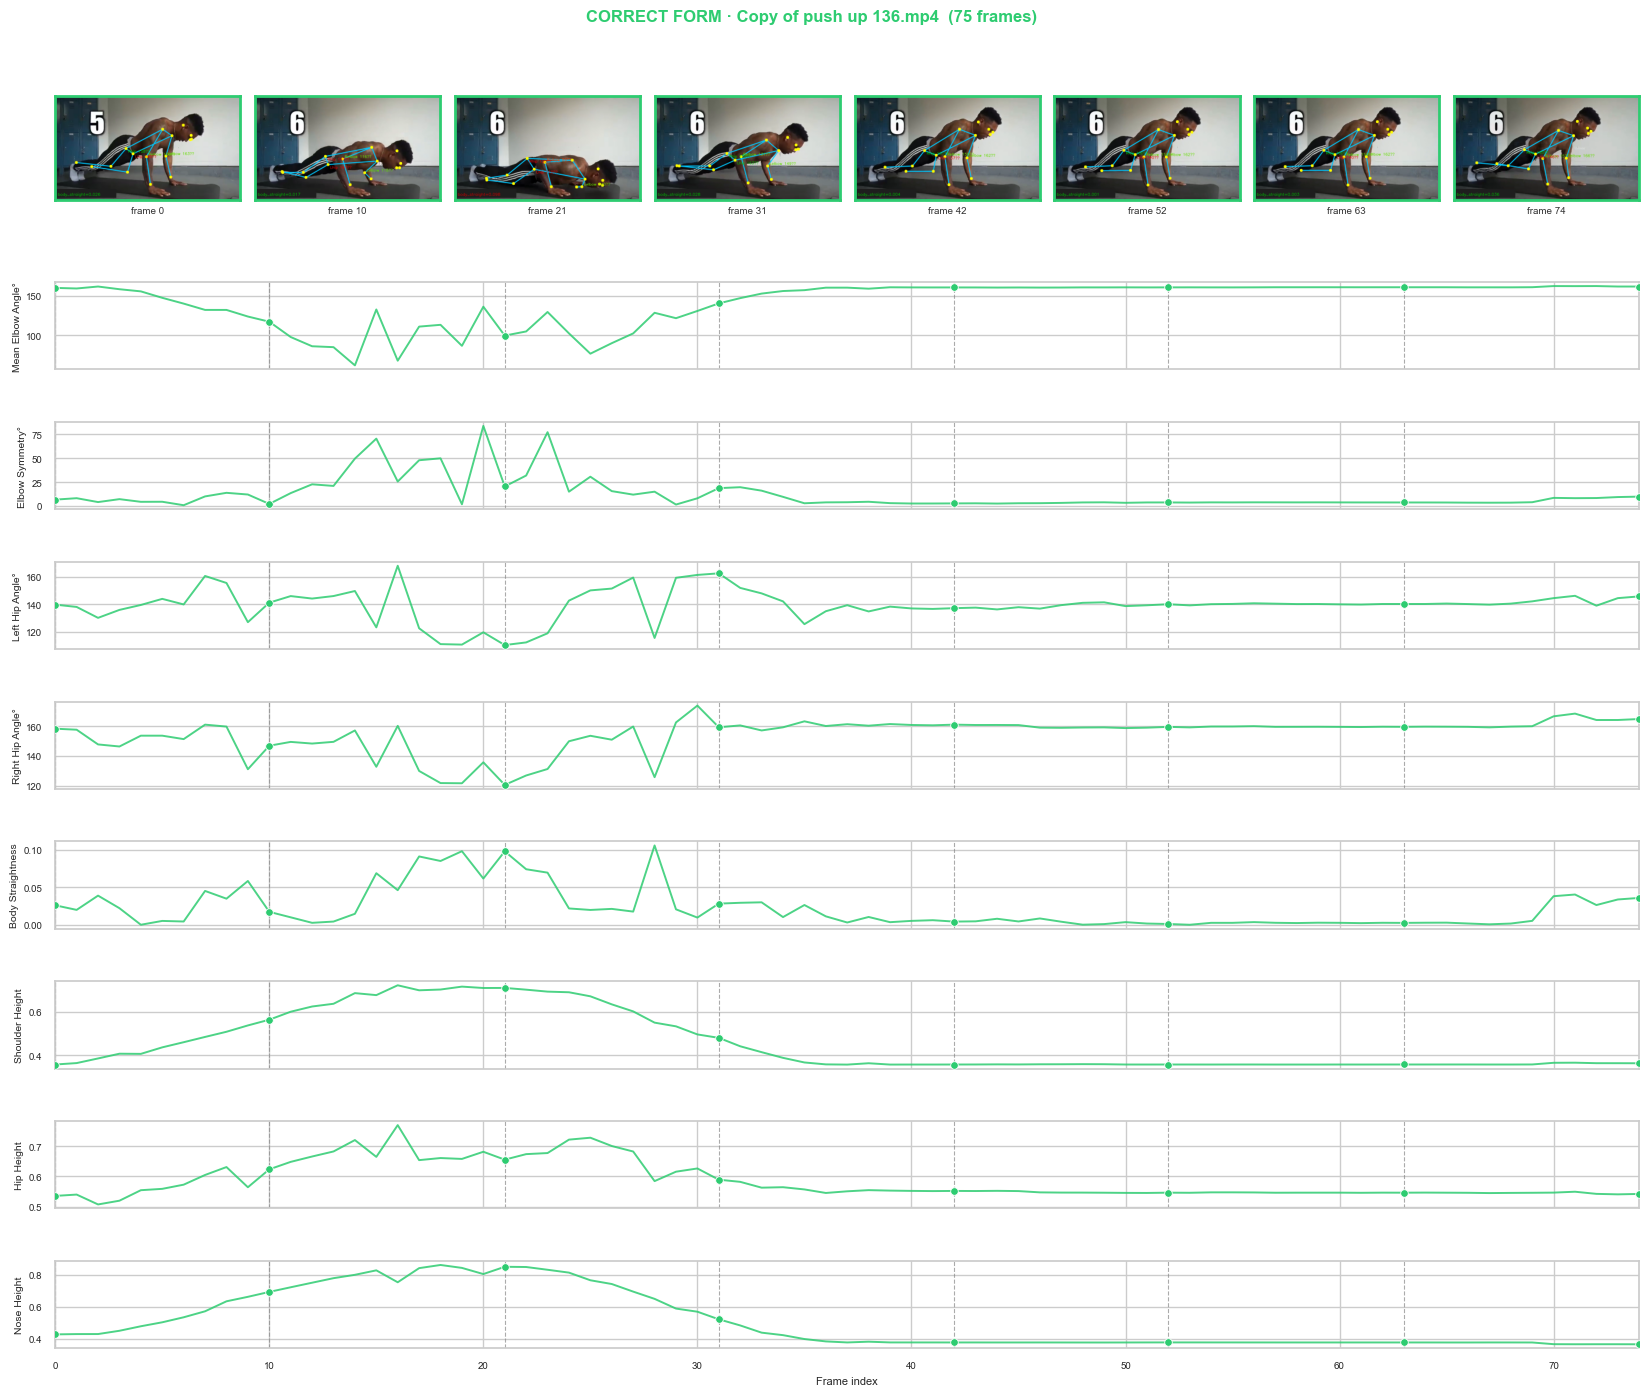


→ Wrong video   : 7.mp4
  Processing 7.mp4 … 110 frames extracted.
  Saved → fig_video_wrong.png


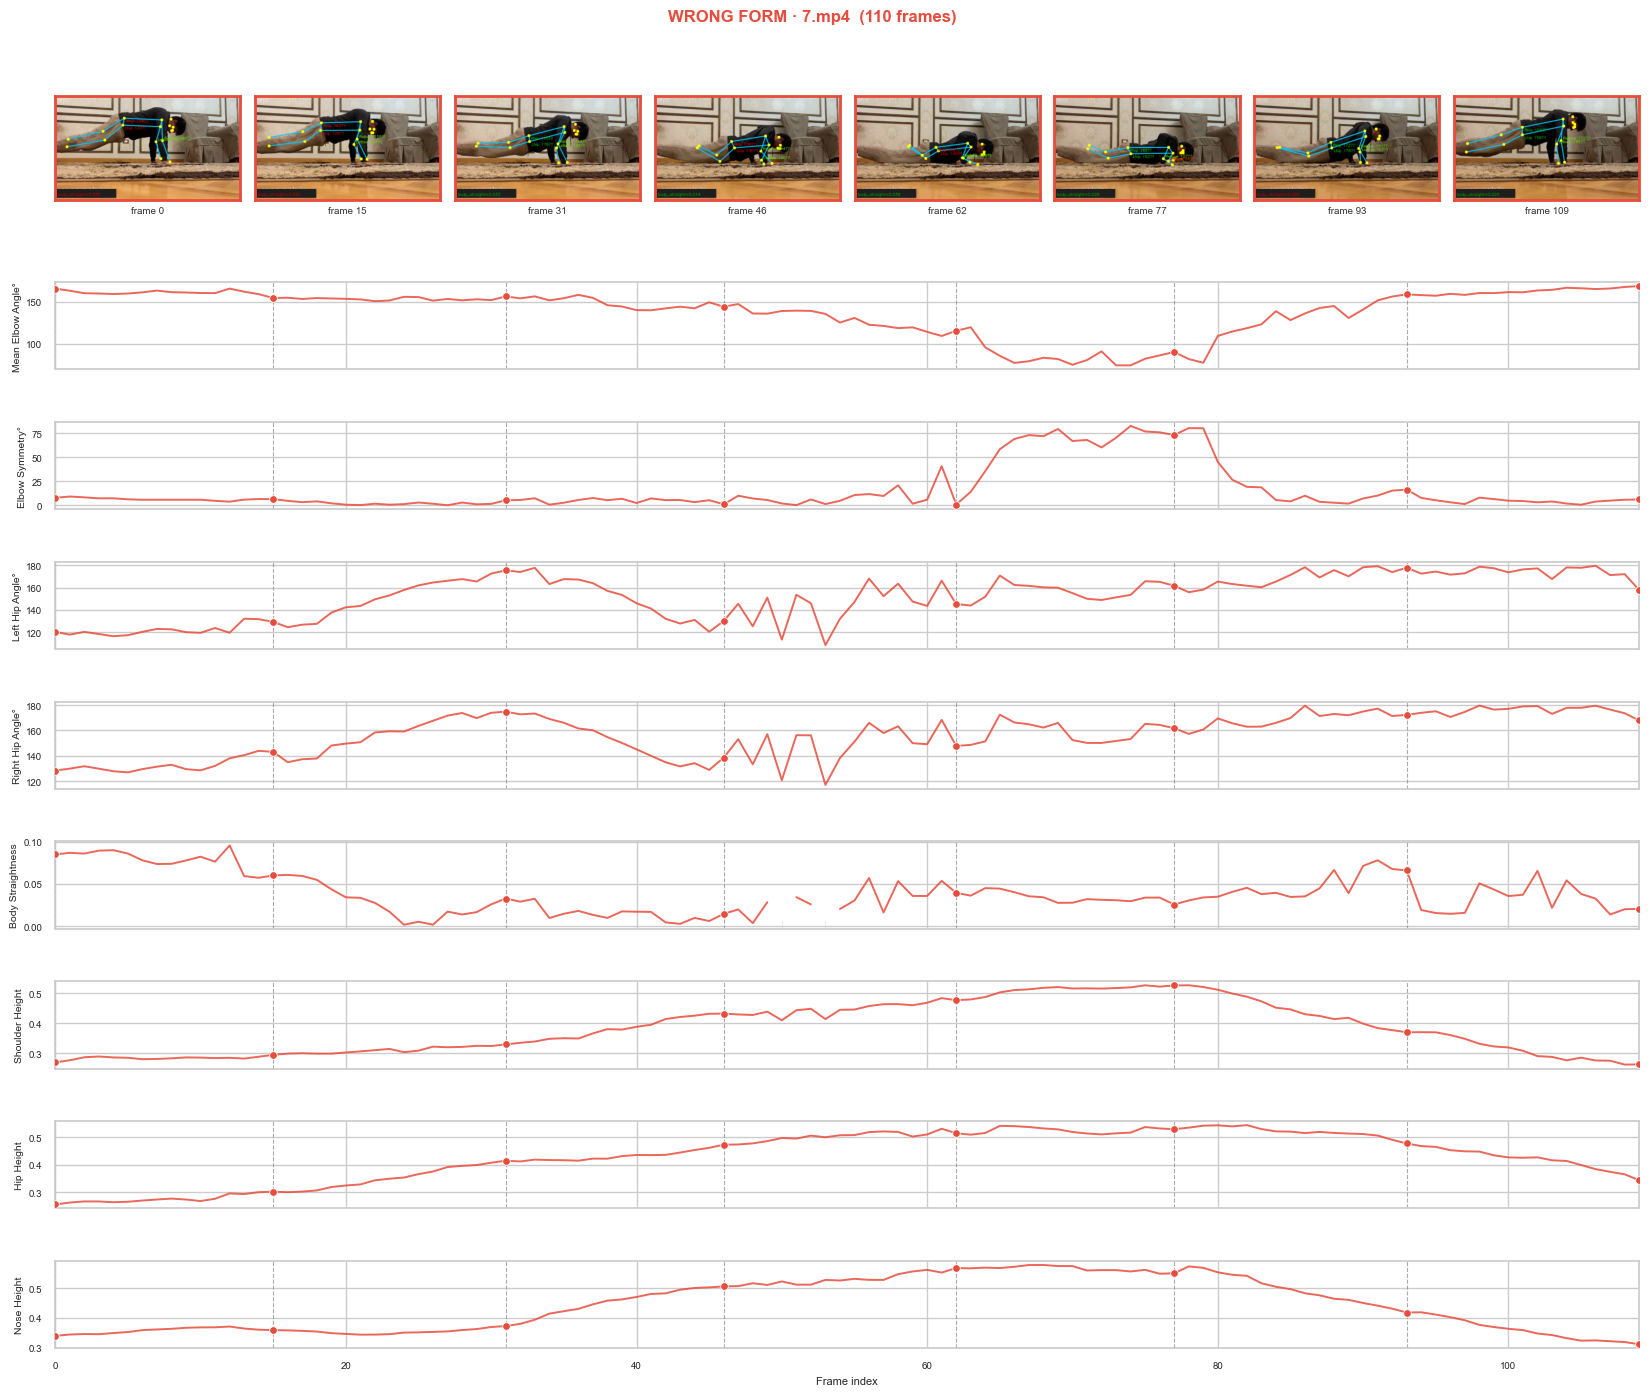

In [18]:

# ─────────────────────────────────────────────────────────────────────────────
#  Config — change these to visualise a different pair of videos
# ─────────────────────────────────────────────────────────────────────────────
VIDEO_IDX_CORRECT = 15  # index into the sorted correct-form video list
VIDEO_IDX_WRONG   = 20  # index into the sorted wrong-form   video list
N_DISPLAY_FRAMES  = 8   # how many evenly-sampled frames to show in the strip

# Key features to plot in the time-series strip
TS_FEATURES = [
    'mean_elbow_angle',
    'elbow_symmetry',
    'left_hip_angle',
    'right_hip_angle',
    'body_straightness',
    'shoulder_height_norm',
    'hip_height_norm',
    'nose_height_norm',
]

# ─────────────────────────────────────────────────────────────────────────────
#  Helpers
# ─────────────────────────────────────────────────────────────────────────────

def draw_skeleton_on_frame(frame_bgr, kps_17x3, conf_thresh=0.3):
    """Draw gold skeleton + cyan keypoints. Returns a copy."""
    img = frame_bgr.copy()
    for i, j in SKELETON:
        if kps_17x3[i, 2] > conf_thresh and kps_17x3[j, 2] > conf_thresh:
            p1 = (int(kps_17x3[i, 0]), int(kps_17x3[i, 1]))
            p2 = (int(kps_17x3[j, 0]), int(kps_17x3[j, 1]))
            cv2.line(img, p1, p2, (255, 200, 0), 2, cv2.LINE_AA)
    for k in range(17):
        if kps_17x3[k, 2] > conf_thresh:
            cx, cy = int(kps_17x3[k, 0]), int(kps_17x3[k, 1])
            cv2.circle(img, (cx, cy), 5, (0, 255, 255), -1)
    return img


def annotate_frame(frame_bgr, kps_17x3, feats, conf_thresh=0.3):
    """Overlay feature values on frame."""
    img = frame_bgr.copy()
    h, w = img.shape[:2]

    def kp(i):
        if kps_17x3[i, 2] > conf_thresh:
            return (int(kps_17x3[i, 0]), int(kps_17x3[i, 1]))
        return None

    # Elbow angles at elbow joints
    for side, el_i, key in [('L', 7, 'left_elbow_angle'), ('R', 8, 'right_elbow_angle')]:
        el = kp(el_i)
        v  = feats.get(key, np.nan)
        if el and not np.isnan(v):
            col = (0, 220, 100) if v > 90 else (0, 70, 255)
            cv2.putText(img, f'{side}elbow {v:.0f}°',
                        (el[0] + 7, el[1] - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, col, 1, cv2.LINE_AA)

    # Hip angles at hip joints
    for side, hi_i, key in [('L', 11, 'left_hip_angle'), ('R', 12, 'right_hip_angle')]:
        hi = kp(hi_i)
        v  = feats.get(key, np.nan)
        if hi and not np.isnan(v):
            col = (0, 200, 0) if v > 150 else (0, 0, 230)
            cv2.putText(img, f'{side}hip {v:.0f}°',
                        (hi[0] + 7, hi[1] + 14),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, col, 1, cv2.LINE_AA)

    # Body straightness — bottom-left badge
    bs = feats.get('body_straightness', np.nan)
    if not np.isnan(bs):
        badge_col = (0, 180, 0) if bs < 0.04 else (0, 0, 200)
        cv2.rectangle(img, (5, h - 38), (210, h - 8), (30, 30, 30), -1)
        cv2.putText(img, f'body_straight={bs:.3f}',
                    (9, h - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, badge_col, 1, cv2.LINE_AA)
    return img


def process_video(video_path: Path, pose_model):
    """
    Run pose detection on every frame, compute features.
    Returns:
        frames_bgr  : list of BGR ndarrays
        feat_seq    : list of feature dicts
        kps_seq     : list of (17,3) arrays (or None)
    """
    import sys
    sys.path.insert(0, str(ROOT))
    from realtime.features import extract_frame_features

    cap = cv2.VideoCapture(str(video_path))
    frames_bgr, feat_seq, kps_seq = [], [], []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        results = pose_model(frame, verbose=False)
        kps_arr = None
        if results and results[0].keypoints is not None:
            kps = results[0].keypoints.data.cpu().numpy()
            if kps.shape[0] > 0:
                best = int(np.argmax(kps[:, :, 2].mean(axis=1)))
                kps_arr = kps[best]
        h_f, w_f = frame.shape[:2]
        feats = extract_frame_features(kps_arr, h_f, w_f) if kps_arr is not None else \
                {c: np.nan for c in FEATURE_COLS}
        frames_bgr.append(frame)
        feat_seq.append(feats)
        kps_seq.append(kps_arr)
    cap.release()
    return frames_bgr, feat_seq, kps_seq


def make_feature_video_figure(video_path: Path, pose_model, label: str,
                               n_display: int = N_DISPLAY_FRAMES,
                               save_path: Path = None):
    """
    Build the combined frame-strip + feature time-series figure for one video.
    """
    print(f'  Processing {video_path.name} …', end=' ', flush=True)
    frames_bgr, feat_seq, kps_seq = process_video(video_path, pose_model)
    n_frames = len(frames_bgr)
    print(f'{n_frames} frames extracted.')

    # ── Choose which frames to display ──────────────────────────────────────
    display_idx = np.linspace(0, n_frames - 1, n_display, dtype=int).tolist()

    # ── Build annotated thumbnail images ─────────────────────────────────────
    thumb_h = 180   # fixed thumbnail height (pixels)
    thumbs  = []
    for fi in display_idx:
        frm = frames_bgr[fi]
        kps = kps_seq[fi]
        fts = feat_seq[fi]
        if kps is not None:
            frm = draw_skeleton_on_frame(frm, kps)
            frm = annotate_frame(frm, kps, fts)
        # Resize to fixed height
        h0, w0 = frm.shape[:2]
        scale  = thumb_h / h0
        frm_rs = cv2.resize(frm, (int(w0 * scale), thumb_h))
        thumbs.append(cv2.cvtColor(frm_rs, cv2.COLOR_BGR2RGB))

    # ── Build feature time-series matrices ───────────────────────────────────
    n_ts = len(TS_FEATURES)
    ts_vals = {f: [d.get(f, np.nan) for d in feat_seq] for f in TS_FEATURES}

    # ── Layout: 1 row of frames + n_ts rows of feature plots ────────────────
    n_rows   = 1 + n_ts
    fig_w    = max(16, n_display * 2.2)
    fig_h    = 2.4 + n_ts * 1.5

    fig = plt.figure(figsize=(fig_w, fig_h), constrained_layout=False)
    clr = COLOR[label]

    # GridSpec: frame strip uses ~28% height, rest shared by feature plots
    gs = fig.add_gridspec(n_rows, n_display,
                          height_ratios=[2.8] + [1.5] * n_ts,
                          hspace=0.55, wspace=0.08,
                          left=0.07, right=0.97, top=0.93, bottom=0.04)

    # ── Row 0: frame thumbnails ───────────────────────────────────────────────
    for col_i, (fi, thumb) in enumerate(zip(display_idx, thumbs)):
        ax_img = fig.add_subplot(gs[0, col_i])
        ax_img.imshow(thumb)
        ax_img.set_xticks([]); ax_img.set_yticks([])
        for spine in ax_img.spines.values():
            spine.set_edgecolor(clr); spine.set_linewidth(2)
        ax_img.set_xlabel(f'frame {fi}', fontsize=7, color='#333333')

    # ── Rows 1–n_ts: feature time-series ─────────────────────────────────────
    frame_x = np.arange(n_frames)

    for row_i, feat in enumerate(TS_FEATURES, start=1):
        # Merge all n_display columns into a single wide axis
        ax_ts = fig.add_subplot(gs[row_i, :])
        vals  = np.array(ts_vals[feat], dtype=float)

        # Plot the signal
        ax_ts.plot(frame_x, vals, color=clr, lw=1.4, alpha=0.85)

        # Shade NaN gaps
        nan_mask = np.isnan(vals)
        if nan_mask.any():
            ax_ts.fill_between(frame_x, ax_ts.get_ylim()[0], ax_ts.get_ylim()[1],
                               where=nan_mask, color='lightgrey', alpha=0.4,
                               transform=ax_ts.get_xaxis_transform())

        # Vertical dashed lines at displayed frames
        for fi in display_idx:
            ax_ts.axvline(fi, color='#888888', lw=0.8, ls='--', alpha=0.7)

        # Scatter dots at displayed frame positions
        show_vals = [vals[fi] if not np.isnan(vals[fi]) else np.nan for fi in display_idx]
        ax_ts.scatter(display_idx, show_vals, s=30, color=clr,
                      zorder=5, edgecolors='white', linewidths=0.6)

        ax_ts.set_xlim(0, n_frames - 1)
        ax_ts.set_ylabel(FEAT_LABELS[feat].replace(' (°)', '°')
                                          .replace(' (norm)', '')
                                          .replace(' (norm dist)', ''),
                          fontsize=7.5, labelpad=3)
        ax_ts.tick_params(axis='both', labelsize=7)
        if row_i < n_ts:
            ax_ts.set_xticklabels([])
        else:
            ax_ts.set_xlabel('Frame index', fontsize=8)

    form_str = label.upper() + ' FORM'
    fig.suptitle(f'{form_str} · {video_path.name}  ({n_frames} frames)',
                 fontsize=12, fontweight='bold', color=clr, y=0.97)

    if save_path:
        fig.savefig(save_path, dpi=140, bbox_inches='tight')
        print(f'  Saved → {save_path.name}')

    plt.show()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
#  Main: load YOLO, pick videos, build figures
# ─────────────────────────────────────────────────────────────────────────────
if not HAS_CV2:
    print('opencv-python is required for this section.')
else:
    from ultralytics import YOLO as _YOLO

    pose_cfg_path = ROOT / 'keypoint_detector' / 'best_model_choice.json'
    _pose_id      = json.loads(pose_cfg_path.read_text())['model_id']
    _pose_model   = _YOLO(str(ROOT / 'keypoint_detector' / _pose_id))
    print(f'Pose model loaded: {_pose_id}')

    correct_vids = sorted(VIDEO_CORRECT.glob('*.mp4')) + sorted(VIDEO_CORRECT.glob('*.mov'))
    wrong_vids   = sorted(VIDEO_WRONG.glob('*.mp4'))   + sorted(VIDEO_WRONG.glob('*.mov'))

    print(f'Available correct videos: {len(correct_vids)}')
    print(f'Available wrong   videos: {len(wrong_vids)}')

    _vid_c = correct_vids[VIDEO_IDX_CORRECT]
    _vid_w = wrong_vids[VIDEO_IDX_WRONG]

    print(f'\n→ Correct video : {_vid_c.name}')
    fig_c = make_feature_video_figure(
        _vid_c, _pose_model, label='correct',
        save_path=FEAT_DIR.parent / 'fig_video_correct.png'
    )

    print(f'\n→ Wrong video   : {_vid_w.name}')
    fig_w = make_feature_video_figure(
        _vid_w, _pose_model, label='wrong',
        save_path=FEAT_DIR.parent / 'fig_video_wrong.png'
    )
